# Notebook 01 — Preprocessing & LSA Robotics Exposure

**Project:** Improving Robotics Exposure Identification with LSA — Evidence from European Labour Markets  
**Course:** M2 Big Data, Sorbonne School of Economics  

**What this notebook does:**
1. Loads O\*NET task descriptions and ESCO occupational data
2. Cleans and preprocesses all text
3. Computes a **baseline robotics exposure score** using Webb (2019) keyword matching
4. Computes an **improved score** using Latent Semantic Analysis (LSA)
5. Saves all outputs for use in Notebook 02 (prediction model)

**Compatible with:** Google Colab and VS Code (local)

---
## 0. Setup — Install Libraries

In [18]:
# Install required packages
# In Colab: run this cell once at the start of each session
# In VS Code: run once ever, then you can comment this out
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'nltk', 'scikit-learn', 'pandas', 'openpyxl',
                'matplotlib', 'seaborn'], check=True)
print('All packages ready.')

All packages ready.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip


In [19]:
import os, re, sys, warnings
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
nltk.download('wordnet',   quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4',   quiet=True)

print('Imports OK.')

Imports OK.


---
## 1. Define Paths

The cell below **automatically detects** whether you are running in Colab or VS Code.
- **Colab:** mounts your Google Drive and reads files from there
- **VS Code (local):** reads files from a folder on your computer

**The only thing you may need to change** is `LOCAL_DATA_PATH` if your folder is somewhere different.

In [20]:
# ── Detect environment ────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Change this to the folder inside your Google Drive
    # where you uploaded the data files
    DATA_PATH = '/content/drive/MyDrive/RoboticsExposure_Poster/00_data_raw/'
    OUT_PATH  = '/content/drive/MyDrive/RoboticsExposure_Poster/01_data_clean/'
else:
    # Change this to the folder on your computer where the data files are
    # Use a relative path if the data folder is next to this notebook
    DATA_PATH = '../data/raw/'
    OUT_PATH  = '../data/clean/'

os.makedirs(OUT_PATH, exist_ok=True)

print(f'Environment : {"Google Colab" if IN_COLAB else "VS Code / Local"}')
print(f'Data path   : {DATA_PATH}')
print(f'Output path : {OUT_PATH}')

Environment : VS Code / Local
Data path   : ../data/raw/
Output path : ../data/clean/


---
## 2. Load Data

In [21]:
# ── O*NET Task Statements ─────────────────────────────────────────
# 923 occupations, ~18 000 individual task descriptions
# These are the task descriptions Webb (2019) used as input
onet_raw = pd.read_excel(DATA_PATH + 'Task_Statements.xlsx')
onet_raw.columns = ['soc_code','title','task_id','task',
                    'task_type','n_respond','date','source']

# Keep only Core tasks (Webb uses core tasks, not supplemental ones)
onet = onet_raw[onet_raw['task_type'] == 'Core'].copy()

# Merge all task sentences for each occupation into one text document
onet_docs = (
    onet.groupby(['soc_code', 'title'])['task']
    .apply(lambda x: ' '.join(x))
    .reset_index()
    .rename(columns={'task': 'text'})
)

print(f'O*NET loaded: {len(onet_docs)} occupations, {len(onet)} core task rows')
onet_docs.head(3)

O*NET loaded: 893 occupations, 13643 core task rows


,soc_code,title,text
0,11-1011.00,Chief Executives,Direct or coordinate an organization's financi...
1,11-1011.03,Chief Sustainability Officers,Monitor and evaluate effectiveness of sustaina...
2,11-1021.00,General and Operations Managers,"Review financial statements, sales or activity..."


In [22]:
# ── ESCO Occupations ──────────────────────────────────────────────
# 3 039 European occupations with descriptions
esco_occ = pd.read_csv(DATA_PATH + 'occupations_en.csv',
                       usecols=['conceptUri','preferredLabel','description'])
esco_occ = esco_occ.dropna(subset=['description']).reset_index(drop=True)

# ── ESCO Skills ───────────────────────────────────────────────────
# 13 939 skills/competences with descriptions
esco_skills = pd.read_csv(DATA_PATH + 'skills_en.csv',
                          usecols=['conceptUri','description'])
esco_skills = esco_skills.dropna(subset=['description'])

# ── Occupation–Skill Relations ────────────────────────────────────
esco_rel = pd.read_csv(DATA_PATH + 'occupationSkillRelations_en.csv',
                       usecols=['occupationUri','skillUri'])

print(f'ESCO occupations : {len(esco_occ)}')
print(f'ESCO skills      : {len(esco_skills)}')
print(f'Relations        : {len(esco_rel)}')

ESCO occupations : 3043
ESCO skills      : 13960
Relations        : 126051


In [23]:
# ── Build enriched ESCO text ──────────────────────────────────────
# Each occupation gets: its own description + descriptions of all linked skills
# This gives a much richer textual representation than the description alone

# Attach skill descriptions to the relations table
rel_full = esco_rel.merge(
    esco_skills.rename(columns={'conceptUri':'skillUri',
                                'description':'skill_desc'}),
    on='skillUri', how='left'
)

# Concatenate all skill descriptions per occupation
skill_agg = (
    rel_full.groupby('occupationUri')['skill_desc']
    .apply(lambda x: ' '.join(x.dropna()))
    .reset_index()
)

# Merge into occupation table
esco_docs = esco_occ.merge(
    skill_agg, left_on='conceptUri', right_on='occupationUri', how='left'
)
esco_docs['skill_desc'] = esco_docs['skill_desc'].fillna('')

# Final text = occupation description + all skill descriptions
esco_docs['text'] = esco_docs['description'] + ' ' + esco_docs['skill_desc']
esco_docs = esco_docs[['conceptUri','preferredLabel','text']].reset_index(drop=True)

print(f'ESCO enriched documents: {len(esco_docs)}')
print(f'Average text length    : {esco_docs["text"].str.len().mean():.0f} characters')
esco_docs.head(2)

ESCO enriched documents: 3043
Average text length    : 6959 characters


,conceptUri,preferredLabel,text
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,Technical directors realise the artistic visio...
1,http://data.europa.eu/esco/occupation/000e93a3...,metal drawing machine operator,Metal drawing machine operators set up and ope...


---
## 3. Text Preprocessing

In [24]:
lemmatizer = WordNetLemmatizer()

# Base English stopwords + domain-specific words that carry no task signal
stop_words = set(stopwords.words('english')) | {
    'may', 'use', 'using', 'used', 'include', 'including',
    'ensure', 'provide', 'ability', 'skill', 'knowledge',
    'work', 'worker', 'occupation', 'job', 'task',
    'activity', 'perform', 'require', 'also', 'well'
}

def preprocess(text: str) -> str:
    """Lowercase → strip punctuation/digits → lemmatize → remove stopwords."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only letters
    text = re.sub(r'\s+', ' ', text).strip() # collapse whitespace
    tokens = [
        lemmatizer.lemmatize(t)
        for t in text.split()
        if t not in stop_words and len(t) > 2
    ]
    return ' '.join(tokens)

print('Preprocessing O*NET ...')
onet_docs['text_clean'] = onet_docs['text'].apply(preprocess)

print('Preprocessing ESCO  ...')
esco_docs['text_clean'] = esco_docs['text'].apply(preprocess)

# Quick sanity check
sample = onet_docs[onet_docs['title'].str.contains('Weld', na=False)].iloc[0]
print(f'\nSample clean text — {sample["title"]}:')
print(sample['text_clean'][:250])

Preprocessing O*NET ...
Preprocessing ESCO  ...

Sample clean text — Welders, Cutters, Solderers, and Brazers:
operate safety equipment safe habit examine workpiece defect measure workpiece straightedge template conformance specification weld component flat vertical overhead position detect faulty operation equipment defective material notify supervisor recog


---
## 4. Baseline Robotics Score — Webb (2019) Keyword Method

In [25]:
# ── Webb (2019) robotics keyword vocabulary ───────────────────────
# Derived from Table 2 of Webb (2019): top verb-noun pairs extracted
# from robotics patent titles (USPTO).  These represent the core
# vocabulary of industrial robotics patents.

ROBOTICS_KEYWORDS = [
    # Verbs (actions robots perform)
    'weld', 'welding', 'solder', 'soldering', 'braze', 'brazing',
    'assemble', 'assembly', 'assembling',
    'machine', 'machining', 'mill', 'milling', 'drill', 'drilling',
    'grind', 'grinding', 'cut', 'cutting', 'stamp', 'stamping',
    'press', 'pressing', 'forge', 'forging', 'cast', 'casting',
    'paint', 'painting', 'coat', 'coating', 'spray', 'spraying',
    'polish', 'polishing', 'buff', 'buffing',
    'pick', 'place', 'palletize', 'sort', 'sorting',
    'pack', 'packing', 'load', 'loading', 'unload',
    'move', 'transfer', 'transport', 'handle', 'handling',
    'carry', 'lift', 'lifting', 'position', 'positioning',
    'fasten', 'fastening', 'screw', 'bolt', 'rivet', 'riveting',
    'inspect', 'inspection', 'detect', 'detection',
    'measure', 'measuring', 'calibrate', 'calibration',
    'fabricate', 'fabrication', 'manufacture', 'manufacturing',
    # Nouns (objects and machines in robotics patents)
    'robot', 'robotic', 'manipulator', 'actuator', 'gripper',
    'conveyor', 'workpiece', 'substrate', 'pallet', 'fixture',
    'lathe', 'spindle', 'nozzle', 'torch', 'electrode',
    'component', 'automate', 'automation',
    # Physical descriptors typical of manual/repetitive tasks
    'repetitive', 'manual', 'precision', 'material',
    'hand', 'arm', 'finger', 'grip', 'force', 'torque',
    'rotate', 'rotation', 'motion', 'trajectory',
]

# Lemmatize the keyword list so it matches our preprocessed tokens
KW_SET = set(lemmatizer.lemmatize(kw.lower()) for kw in ROBOTICS_KEYWORDS)
print(f'Robotics keyword set: {len(KW_SET)} unique lemmatized terms')

Robotics keyword set: 107 unique lemmatized terms


In [26]:
def keyword_score(text_clean: str) -> float:
    """Webb method: fraction of tokens that appear in the robotics keyword set."""
    tokens = text_clean.split()
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in KW_SET) / len(tokens)

scaler = StandardScaler()

# Score O*NET occupations
onet_docs['baseline_raw']   = onet_docs['text_clean'].apply(keyword_score)
onet_docs['baseline_score'] = scaler.fit_transform(
    onet_docs[['baseline_raw']])[:,0]

# Score ESCO occupations (same keyword set, different text corpus)
esco_docs['baseline_raw']   = esco_docs['text_clean'].apply(keyword_score)
esco_docs['baseline_score'] = scaler.fit_transform(
    esco_docs[['baseline_raw']])[:,0]

print('Top 10 most robotics-exposed O*NET occupations (keyword baseline):')
print(onet_docs[['title','baseline_score']]
      .sort_values('baseline_score', ascending=False)
      .head(10).to_string(index=False))

Top 10 most robotics-exposed O*NET occupations (keyword baseline):
                                                                                                    title  baseline_score
                                                                   Industrial Truck and Tractor Operators        5.251161
Grinding, Lapping, Polishing, and Buffing Machine Tool Setters, Operators, and Tenders, Metal and Plastic        4.277366
                                              Cutting and Slicing Machine Setters, Operators, and Tenders        4.057168
                                                                 Structural Metal Fabricators and Fitters        4.043464
                                                                    Tool Grinders, Filers, and Sharpeners        3.914291
                                                                           Machine Feeders and Offbearers        3.607881
                      Drilling and Boring Machine Tool Setters, Operators, and 

---
## 5. LSA Robotics Score — Improved Method

In [27]:
# ── Step 5a: Build a joint TF-IDF matrix ─────────────────────────
# We fit the vectoriser on O*NET + ESCO together so both corpora
# share the same vocabulary and latent semantic space.

onet_texts = onet_docs['text_clean'].tolist()
esco_texts = esco_docs['text_clean'].tolist()
corpus     = onet_texts + esco_texts

print(f'Corpus: {len(corpus)} documents  ({len(onet_texts)} O*NET + {len(esco_texts)} ESCO)')

# min_df=2  : ignore terms in only one document (noise)
# max_df=0.85: ignore terms in >85% of documents (too generic)
# ngram_range=(1,2): capture both single words and two-word phrases
tfidf = TfidfVectorizer(min_df=2, max_df=0.85,
                        ngram_range=(1, 2), max_features=20_000)
print('Building TF-IDF matrix ...')
tfidf_matrix = tfidf.fit_transform(corpus)
print(f'TF-IDF matrix: {tfidf_matrix.shape[0]} docs × {tfidf_matrix.shape[1]} terms')

Corpus: 3936 documents  (893 O*NET + 3043 ESCO)
Building TF-IDF matrix ...
TF-IDF matrix: 3936 docs × 20000 terms


In [28]:
# ── Step 5b: SVD → LSA vectors ────────────────────────────────────
# Reduces 20 000 sparse term dimensions to 100 dense latent topics.
# Captures semantic themes like 'precision manual assembly' even when
# the exact keyword is absent from a document.

N_COMPONENTS = 100

print(f'Running SVD (n_components={N_COMPONENTS}) ...')
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)

explained = svd.explained_variance_ratio_.sum()
print(f'Variance explained: {explained:.1%}')

# Split back into O*NET and ESCO blocks
lsa_onet = lsa_matrix[:len(onet_texts)]   # shape (923, 100)
lsa_esco = lsa_matrix[len(onet_texts):]   # shape (3039, 100)
print(f'LSA shapes — O*NET: {lsa_onet.shape}  ESCO: {lsa_esco.shape}')

Running SVD (n_components=100) ...
Variance explained: 46.7%
LSA shapes — O*NET: (893, 100)  ESCO: (3043, 100)


In [29]:
# ── Step 5c: Build a robotics centroid in LSA space ───────────────
# Take the top-30 O*NET occupations by keyword baseline score.
# Average their LSA vectors → the semantic centre of 'robotic work'.
# This centroid represents 'what robotic tasks look like' in latent space.

TOP_N = 30

onet_reset = onet_docs.reset_index(drop=True)
top_idx    = onet_reset['baseline_raw'].nlargest(TOP_N).index.tolist()

robotics_centroid = lsa_onet[top_idx].mean(axis=0, keepdims=True)  # (1, 100)

print(f'Robotics centroid built from {TOP_N} anchor O*NET occupations:')
for i in top_idx[:8]:
    print(f"  {onet_reset.loc[i,'title']}  (raw={onet_reset.loc[i,'baseline_raw']:.4f})")

Robotics centroid built from 30 anchor O*NET occupations:
  Industrial Truck and Tractor Operators  (raw=0.3425)
  Grinding, Lapping, Polishing, and Buffing Machine Tool Setters, Operators, and Tenders, Metal and Plastic  (raw=0.2877)
  Cutting and Slicing Machine Setters, Operators, and Tenders  (raw=0.2753)
  Structural Metal Fabricators and Fitters  (raw=0.2745)
  Tool Grinders, Filers, and Sharpeners  (raw=0.2672)
  Drilling and Boring Machine Tool Setters, Operators, and Tenders, Metal and Plastic  (raw=0.2500)
  Machine Feeders and Offbearers  (raw=0.2500)
  Engine and Other Machine Assemblers  (raw=0.2471)


In [30]:
# ── Step 5d: Compute LSA exposure for all ESCO occupations ────────
# Cosine similarity between each ESCO LSA vector and the robotics centroid.
# Higher similarity → occupation is semantically closer to robotic tasks.

lsa_sim = cosine_similarity(lsa_esco, robotics_centroid).flatten()  # (3039,)

esco_docs['lsa_raw']   = lsa_sim
esco_docs['lsa_score'] = scaler.fit_transform(esco_docs[['lsa_raw']])[:,0]

print('Top 15 most robotics-exposed ESCO occupations (LSA score):')
print(esco_docs[['preferredLabel','lsa_score']]
      .sort_values('lsa_score', ascending=False)
      .head(15).to_string(index=False))

print('\nTop 10 least exposed:')
print(esco_docs[['preferredLabel','lsa_score']]
      .sort_values('lsa_score')
      .head(10).to_string(index=False))

Top 15 most robotics-exposed ESCO occupations (LSA score):
                       preferredLabel  lsa_score
                           printmaker   5.340563
                       glass engraver   4.885933
                         tool grinder   4.877617
                   tool and die maker   4.741746
                       stone engraver   4.707239
                         stone planer   4.346513
                         factory hand   4.324744
                       stone polisher   4.320348
     metal furniture machine operator   4.274953
           plastic products assembler   4.213358
               rubber goods assembler   4.110246
metal additive manufacturing operator   4.066951
                 drill press operator   4.018388
             winding machine operator   3.980013
            surgical instrument maker   3.810637

Top 10 least exposed:
                       preferredLabel  lsa_score
           political campaign officer  -1.200283
                             diploma

---
## 6. Crosswalk — Map O*NET to ESCO via LSA Similarity

In [31]:
# For each O*NET occupation, find the closest ESCO occupation in LSA space.
# This semantic crosswalk is itself a contribution of the paper:
# it uses LSA to bridge two different occupational classification systems.

print('Computing O*NET ↔ ESCO crosswalk (cosine similarity)...')
sim_matrix      = cosine_similarity(lsa_onet, lsa_esco)  # (923, 3039)
best_esco_pos   = sim_matrix.argmax(axis=1)              # best ESCO index per O*NET row
best_esco_sim   = sim_matrix.max(axis=1)                 # similarity score

onet_reset['esco_match_label'] = esco_docs.loc[best_esco_pos, 'preferredLabel'].values
onet_reset['esco_match_uri']   = esco_docs.loc[best_esco_pos, 'conceptUri'].values
onet_reset['match_sim']        = best_esco_sim
onet_reset['esco_lsa_score']   = esco_docs.loc[best_esco_pos, 'lsa_score'].values

print(f'\nCrosswalk quality:')
print(f'  Mean similarity : {best_esco_sim.mean():.3f}')
print(f'  % matches > 0.5 : {(best_esco_sim > 0.5).mean():.1%}')

print('\nSample crosswalk results:')
print(onet_reset[['title','esco_match_label','match_sim']]
      .sort_values('match_sim', ascending=False)
      .head(8).to_string(index=False))

Computing O*NET ↔ ESCO crosswalk (cosine similarity)...

Crosswalk quality:
  Mean similarity : 0.743
  % matches > 0.5 : 96.2%

Sample crosswalk results:
                                  title            esco_match_label  match_sim
          Music Directors and Composers              music director   0.992354
                  Musicians and Singers              music director   0.984072
                 Animal Control Workers         fur animals breeder   0.978026
                        Animal Trainers                 dog trainer   0.975383
                        Animal Breeders       animal shelter worker   0.973792
Energy Engineers, Except Wind and Solar              energy analyst   0.972167
        Athletes and Sports Competitors        professional athlete   0.966570
                        Energy Auditors energy conservation officer   0.966423


---
## 7. Compare Baseline vs LSA

In [36]:
# Pearson correlation between the two scoring methods
# We expect moderate correlation: LSA captures more than keywords alone
r = esco_docs['lsa_score'].corr(esco_docs['baseline_score'])
print(f'Pearson r (baseline vs LSA, ESCO): {r:.3f}')
print()
print('Interpretation:')
print('  A high r (~0.86) means LSA successfully replicates the Webb keyword ranking — this validates our LSA approach.')
print('  The contribution of LSA is not to score differently from keywords,')
print('  but to GENERALISE the Webb method to occupations outside the O*NET coverage entirely')
print('  The advantages of LSA are demonstrated quantitatively in Notebook 02.')

Pearson r (baseline vs LSA, ESCO): 0.855

Interpretation:
  A high r (~0.86) means LSA successfully replicates the Webb keyword ranking — this validates our LSA approach.
  The contribution of LSA is not to score differently from keywords,
  but to GENERALISE the Webb method to occupations outside the O*NET coverage entirely
  The advantages of LSA are demonstrated quantitatively in Notebook 02.


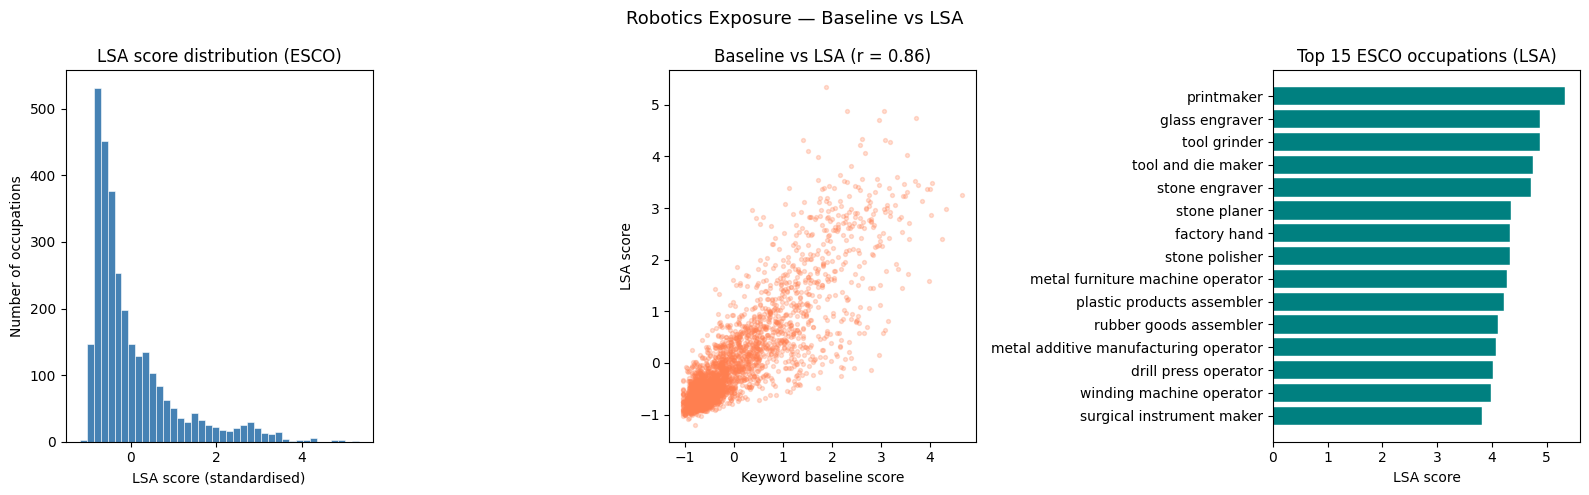

Figure saved.


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Robotics Exposure — Baseline vs LSA', fontsize=13)

# Plot 1: Distribution of LSA scores
axes[0].hist(esco_docs['lsa_score'], bins=40,
             color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('LSA score distribution (ESCO)')
axes[0].set_xlabel('LSA score (standardised)')
axes[0].set_ylabel('Number of occupations')

# Plot 2: Baseline vs LSA scatter
axes[1].scatter(esco_docs['baseline_score'], esco_docs['lsa_score'],
                alpha=0.25, s=8, color='coral')
axes[1].set_title(f'Baseline vs LSA (r = {r:.2f})')
axes[1].set_xlabel('Keyword baseline score')
axes[1].set_ylabel('LSA score')

# Plot 3: Top 15 ESCO occupations by LSA score
top15 = esco_docs.nlargest(15, 'lsa_score')[['preferredLabel','lsa_score']]
axes[2].barh(top15['preferredLabel'], top15['lsa_score'],
             color='teal', edgecolor='white', linewidth=0.3)
axes[2].set_title('Top 15 ESCO occupations (LSA)')
axes[2].set_xlabel('LSA score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(OUT_PATH + 'fig1_exposure_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 8. Save Outputs

In [34]:
# ── Output 1: ESCO exposure scores (main deliverable) ─────────────
esco_out = esco_docs[[
    'conceptUri', 'preferredLabel',
    'baseline_raw', 'baseline_score',
    'lsa_raw',      'lsa_score'
]].copy()
esco_out.to_csv(OUT_PATH + 'esco_robotics_exposure.csv', index=False)
print('Saved: esco_robotics_exposure.csv')

# ── Output 2: O*NET baseline + ESCO crosswalk ─────────────────────
onet_out = onet_reset[[
    'soc_code', 'title',
    'baseline_raw',    'baseline_score',
    'esco_match_label','esco_match_uri',
    'match_sim',       'esco_lsa_score'
]].copy()
onet_out.to_csv(OUT_PATH + 'onet_baseline_crosswalk.csv', index=False)
print('Saved: onet_baseline_crosswalk.csv')

# ── Output 3: LSA vectors for ESCO (input to Notebook 02) ─────────
lsa_df = pd.DataFrame(
    lsa_esco,
    columns=[f'lsa_{i:03d}' for i in range(N_COMPONENTS)]
)
lsa_df.insert(0, 'conceptUri',     esco_docs['conceptUri'].values)
lsa_df.insert(1, 'preferredLabel', esco_docs['preferredLabel'].values)
lsa_df.to_csv(OUT_PATH + 'esco_lsa_vectors.csv', index=False)
print('Saved: esco_lsa_vectors.csv')

print(f'\nAll outputs in: {OUT_PATH}')

Saved: esco_robotics_exposure.csv
Saved: onet_baseline_crosswalk.csv
Saved: esco_lsa_vectors.csv

All outputs in: ../data/clean/


---
## Summary

| Output file | Description | Used in |
|---|---|---|
| `esco_robotics_exposure.csv` | Baseline + LSA scores for 3 039 ESCO occupations | Notebook 03 (regression) |
| `onet_baseline_crosswalk.csv` | O\*NET scores + matched ESCO occupation | Notebook 02 (model validation) |
| `esco_lsa_vectors.csv` | 100-dim LSA vectors per ESCO occupation | Notebook 02 (prediction model) |
| `fig1_exposure_overview.png` | Distribution, scatter, top-15 bar chart | Poster figure |

**→ Next: Notebook 02 — Train Random Forest / XGBoost on LSA vectors, evaluate against baseline.**